# Holdout reliability and tolerance analysis

This notebook answers the questions that one global MAE keeps hiding:

- What fraction of holdout predictions are within **±0.05 mm**?
- What fraction are within **±0.10 mm**?
- How many exceed **one full DOE step**?
- What are the **50th / 75th / 90th / 95th percentiles** of absolute error?
- Which **runs** or **depth levels** are the ugly ones?

It expects the `holdout_predictions.csv` produced by the training script.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------------
PRED_CSV = Path("outputs/optimized_architecture/ensemble_holdout_predictions.csv")
OUT_DIR = PRED_CSV.parent / "reliability_analysis"
DOE_STEP_MM = 0.10
TOLERANCES_MM = [0.05, 0.10, 0.15]
DEPTH_ROUND_DECIMALS = 3

OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Prediction file:", PRED_CSV.resolve())
print("Output dir     :", OUT_DIR.resolve())

Prediction file: D:\MA\AnalyzeSound\notebooks\outputs\optimized_architecture\ensemble_holdout_predictions.csv
Output dir     : D:\MA\AnalyzeSound\notebooks\outputs\optimized_architecture\reliability_analysis


In [2]:
# ------------------------------------------------------------------
# LOAD + BASIC CHECKS
# ------------------------------------------------------------------
df = pd.read_csv(PRED_CSV)
required = ["y_true", "y_pred"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

if "residual" not in df.columns:
    df["residual"] = df["y_true"] - df["y_pred"]
if "abs_error" not in df.columns:
    df["abs_error"] = np.abs(df["residual"])

group_col = "run_id" if "run_id" in df.columns else None
record_col = "record_name" if "record_name" in df.columns else None

df["depth_level"] = df["y_true"].round(DEPTH_ROUND_DECIMALS)

print("Rows:", len(df))
print("Columns:", list(df.columns))
if group_col is not None:
    print("Runs:", df[group_col].nunique())

df.head()


Rows: 343
Columns: ['depth_mm', 'run_id', 'record_name', '__row_id__', 'y_true', 'y_pred', 'y_pred_raw', 'residual', 'abs_error', 'sq_error', 'depth_level']
Runs: 7


,depth_mm,run_id,record_name,__row_id__,y_true,y_pred,y_pred_raw,residual,abs_error,sq_error,depth_level
0,0.1,0503_12_1_6520,0503_12_1_6520__seg018__step018__B1__depth0.10...,5,0.1,0.1,0.132343,0.0,0.0,0.0,0.1
1,0.1,0503_12_1_6520,0503_12_1_6520__seg011__step011__A3__depth0.10...,21,0.1,0.1,0.136596,0.0,0.0,0.0,0.1
2,0.1,0503_9_1_1285,0503_9_1_1285__seg030__step030__C6__depth0.100...,23,0.1,0.1,0.099704,0.0,0.0,0.0,0.1
3,0.1,0503_9_1_1285,0503_9_1_1285__seg029__step029__D2__depth0.100...,24,0.1,0.1,0.103534,0.0,0.0,0.0,0.1
4,0.1,0503_2_1_5344,0503_2_1_5344__seg018__step018__B1__depth0.100...,27,0.1,0.1,0.111511,0.0,0.0,0.0,0.1


In [3]:
# ------------------------------------------------------------------
# OVERALL RELIABILITY SUMMARY
# ------------------------------------------------------------------
def build_reliability_summary(dfp: pd.DataFrame, tolerances_mm):
    out = {
        "n_rows": len(dfp),
        "mae_mm": float(dfp["abs_error"].mean()),
        "rmse_mm": float(np.sqrt(np.mean((dfp["residual"]) ** 2))),
        "bias_mean_mm": float(dfp["residual"].mean()),
        "median_abs_error_mm": float(dfp["abs_error"].quantile(0.50)),
        "p75_abs_error_mm": float(dfp["abs_error"].quantile(0.75)),
        "p90_abs_error_mm": float(dfp["abs_error"].quantile(0.90)),
        "p95_abs_error_mm": float(dfp["abs_error"].quantile(0.95)),
        "max_abs_error_mm": float(dfp["abs_error"].max()),
        "mae_as_fraction_of_step": float(dfp["abs_error"].mean() / DOE_STEP_MM),
    }
    for tol in tolerances_mm:
        out[f"p_abs_error_le_{tol:.2f}_mm"] = float((dfp["abs_error"] <= tol).mean())
        out[f"p_abs_error_gt_{tol:.2f}_mm"] = float((dfp["abs_error"] > tol).mean())
    return pd.DataFrame([out])

overall = build_reliability_summary(df, TOLERANCES_MM)
overall


,n_rows,mae_mm,rmse_mm,bias_mean_mm,median_abs_error_mm,p75_abs_error_mm,p90_abs_error_mm,p95_abs_error_mm,max_abs_error_mm,mae_as_fraction_of_step,p_abs_error_le_0.05_mm,p_abs_error_gt_0.05_mm,p_abs_error_le_0.10_mm,p_abs_error_gt_0.10_mm,p_abs_error_le_0.15_mm,p_abs_error_gt_0.15_mm
0,343,0.022449,0.053179,0.002624,0.0,1.110223e-16,0.1,0.1,0.2,0.22449,0.804665,0.195335,0.970845,0.029155,0.970845,0.029155


In [4]:
# Save the overall summary
overall.to_csv(OUT_DIR / "holdout_reliability_overall.csv", index=False)
print(overall.T)

                                    0
n_rows                   3.430000e+02
mae_mm                   2.244898e-02
rmse_mm                  5.317883e-02
bias_mean_mm             2.623907e-03
median_abs_error_mm      0.000000e+00
p75_abs_error_mm         1.110223e-16
p90_abs_error_mm         1.000000e-01
p95_abs_error_mm         1.000000e-01
max_abs_error_mm         2.000000e-01
mae_as_fraction_of_step  2.244898e-01
p_abs_error_le_0.05_mm   8.046647e-01
p_abs_error_gt_0.05_mm   1.953353e-01
p_abs_error_le_0.10_mm   9.708455e-01
p_abs_error_gt_0.10_mm   2.915452e-02
p_abs_error_le_0.15_mm   9.708455e-01
p_abs_error_gt_0.15_mm   2.915452e-02


In [5]:
# ------------------------------------------------------------------
# THESIS-READY CONCRETE STATEMENTS
# ------------------------------------------------------------------
def pct(x):
    return f"{100*x:.1f}%"

mae = overall.loc[0, "mae_mm"]
p50 = overall.loc[0, "median_abs_error_mm"]
p75 = overall.loc[0, "p75_abs_error_mm"]
p90 = overall.loc[0, "p90_abs_error_mm"]
p95 = overall.loc[0, "p95_abs_error_mm"]

p_le_005 = overall.loc[0, "p_abs_error_le_0.05_mm"] if "p_abs_error_le_0.05_mm" in overall.columns else np.nan
p_le_010 = overall.loc[0, "p_abs_error_le_0.10_mm"] if "p_abs_error_le_0.10_mm" in overall.columns else np.nan
p_gt_010 = overall.loc[0, "p_abs_error_gt_0.10_mm"] if "p_abs_error_gt_0.10_mm" in overall.columns else np.nan

print(f"MAE on the holdout set is {mae:.4f} mm.")
print(f"The median absolute error is {p50:.4f} mm.")
print(f"The 75th percentile absolute error is {p75:.4f} mm.")
print(f"The 90th percentile absolute error is {p90:.4f} mm.")
print(f"The 95th percentile absolute error is {p95:.4f} mm.")
print()
print(f"{pct(p_le_005)} of holdout predictions are within ±0.05 mm.")
print(f"{pct(p_le_010)} of holdout predictions are within ±0.10 mm.")
print(f"{pct(p_gt_010)} of holdout predictions exceed ±0.10 mm.")

MAE on the holdout set is 0.0224 mm.
The median absolute error is 0.0000 mm.
The 75th percentile absolute error is 0.0000 mm.
The 90th percentile absolute error is 0.1000 mm.
The 95th percentile absolute error is 0.1000 mm.

80.5% of holdout predictions are within ±0.05 mm.
97.1% of holdout predictions are within ±0.10 mm.
2.9% of holdout predictions exceed ±0.10 mm.


In [6]:
# ------------------------------------------------------------------
# BY DEPTH LEVEL
# ------------------------------------------------------------------
by_depth = (
    df.groupby("depth_level", as_index=False)
      .agg(
          n_rows=("y_true", "size"),
          mae_mm=("abs_error", "mean"),
          rmse_mm=("residual", lambda s: float(np.sqrt(np.mean(np.square(s))))),
          bias_mean_mm=("residual", "mean"),
          median_abs_error_mm=("abs_error", lambda s: float(s.quantile(0.50))),
          p75_abs_error_mm=("abs_error", lambda s: float(s.quantile(0.75))),
          p90_abs_error_mm=("abs_error", lambda s: float(s.quantile(0.90))),
          p95_abs_error_mm=("abs_error", lambda s: float(s.quantile(0.95))),
      )
      .sort_values("depth_level")
)

for tol in TOLERANCES_MM:
    by_depth[f"p_abs_error_le_{tol:.2f}_mm"] = (
        df.assign(hit=df["abs_error"] <= tol)
          .groupby("depth_level")["hit"]
          .mean()
          .to_numpy()
    )

by_depth.to_csv(OUT_DIR / "holdout_reliability_by_depth.csv", index=False)
by_depth

,depth_level,n_rows,mae_mm,rmse_mm,bias_mean_mm,median_abs_error_mm,p75_abs_error_mm,p90_abs_error_mm,p95_abs_error_mm,p_abs_error_le_0.05_mm,p_abs_error_le_0.10_mm,p_abs_error_le_0.15_mm
0,0.1,35,0.025714,0.060945,-0.025714,0.000000e+00,0.000000e+00,0.1,0.13,0.800000,0.942857,0.942857
1,0.2,35,0.022857,0.063246,-0.011429,0.000000e+00,0.000000e+00,0.1,0.20,0.857143,0.914286,0.914286
2,0.3,35,0.025714,0.050709,-0.002857,5.551115e-17,5.000000e-02,0.1,0.10,0.742857,1.000000,1.000000
3,0.4,35,0.011429,0.041404,-0.005714,0.000000e+00,0.000000e+00,0.0,0.10,0.914286,0.971429,0.971429
4,0.5,35,0.014286,0.037796,-0.002857,0.000000e+00,0.000000e+00,0.1,0.10,0.857143,1.000000,1.000000
5,0.6,28,0.021429,0.046291,0.014286,1.110223e-16,1.110223e-16,0.1,0.10,0.785714,1.000000,1.000000
6,0.7,35,0.028571,0.058554,0.011429,1.110223e-16,5.000000e-02,0.1,0.10,0.742857,0.971429,0.971429
7,0.8,35,0.028571,0.063246,0.017143,0.000000e+00,0.000000e+00,0.1,0.13,0.771429,0.942857,0.942857
8,0.9,35,0.020000,0.044721,0.008571,0.000000e+00,0.000000e+00,0.1,0.10,0.800000,1.000000,1.000000
9,1.0,35,0.025714,0.056061,0.025714,0.000000e+00,0.000000e+00,0.1,0.10,0.771429,0.971429,0.971429


In [7]:
# ------------------------------------------------------------------
# BY RUN
# ------------------------------------------------------------------
if group_col is not None:
    by_run = (
        df.groupby(group_col, as_index=False)
          .agg(
              n_rows=("y_true", "size"),
              mae_mm=("abs_error", "mean"),
              rmse_mm=("residual", lambda s: float(np.sqrt(np.mean(np.square(s))))),
              bias_mean_mm=("residual", "mean"),
              median_abs_error_mm=("abs_error", lambda s: float(s.quantile(0.50))),
              p75_abs_error_mm=("abs_error", lambda s: float(s.quantile(0.75))),
              p90_abs_error_mm=("abs_error", lambda s: float(s.quantile(0.90))),
              p95_abs_error_mm=("abs_error", lambda s: float(s.quantile(0.95))),
          )
          .sort_values("mae_mm")
    )
    for tol in TOLERANCES_MM:
        by_run[f"p_abs_error_le_{tol:.2f}_mm"] = (
            df.assign(hit=df["abs_error"] <= tol)
              .groupby(group_col)["hit"]
              .mean()
              .to_numpy()
        )
    by_run.to_csv(OUT_DIR / "holdout_reliability_by_run.csv", index=False)
    print(by_run)
else:
    print("No run_id column found, so by-run summary was skipped.")

           run_id  n_rows    mae_mm   rmse_mm  bias_mean_mm  \
1  0503_12_2_8250      49  0.002041  0.014286     -0.002041   
5   0503_8_1_5957      49  0.012245  0.034993     -0.012245   
4   0503_6_1_6360      49  0.012245  0.034993     -0.008163   
0  0503_12_1_6520      49  0.012245  0.045175     -0.012245   
6   0503_9_1_1285      49  0.022449  0.058902     -0.022449   
2   0503_2_1_5344      49  0.044898  0.075593      0.044898   
3   0503_3_1_0862      49  0.051020  0.076931      0.030612   

   median_abs_error_mm  p75_abs_error_mm  p90_abs_error_mm  p95_abs_error_mm  \
1         0.000000e+00      5.551115e-17      1.110223e-16      1.110223e-16   
5         0.000000e+00      1.110223e-16      1.000000e-01      1.000000e-01   
4         0.000000e+00      1.110223e-16      1.000000e-01      1.000000e-01   
0         0.000000e+00      5.551115e-17      1.110223e-16      1.000000e-01   
6         0.000000e+00      1.110223e-16      1.000000e-01      1.600000e-01   
2         5.551

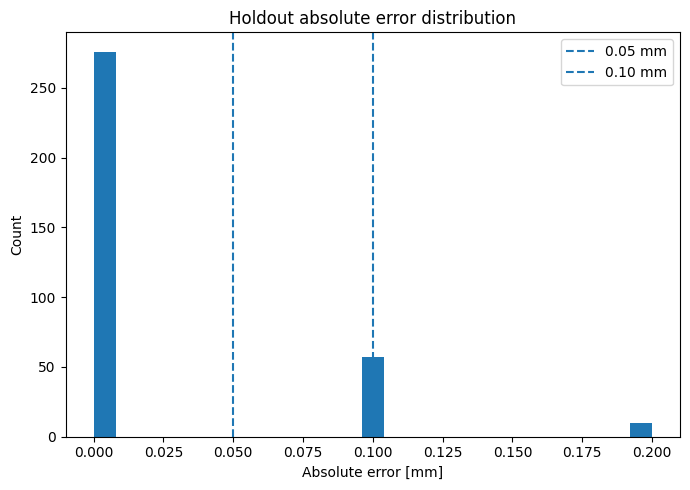

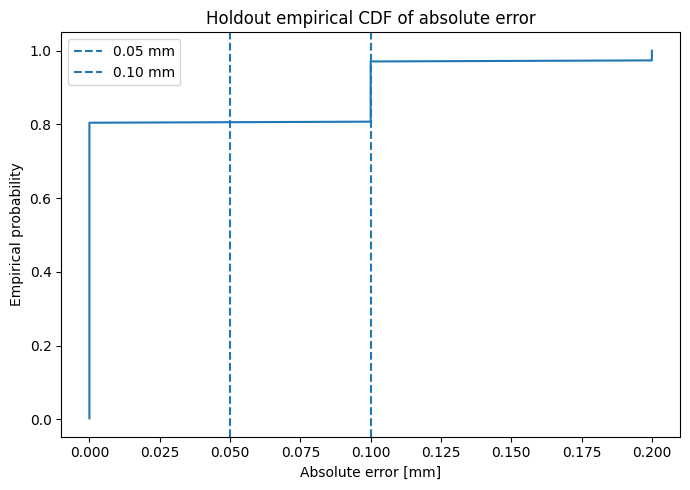

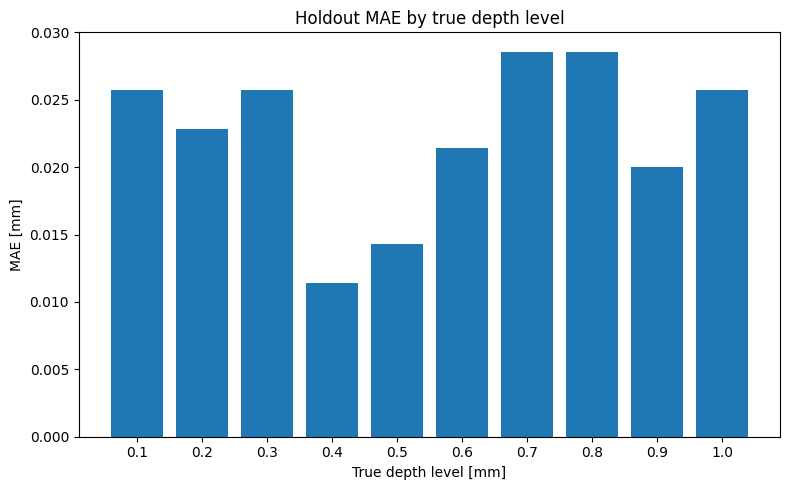

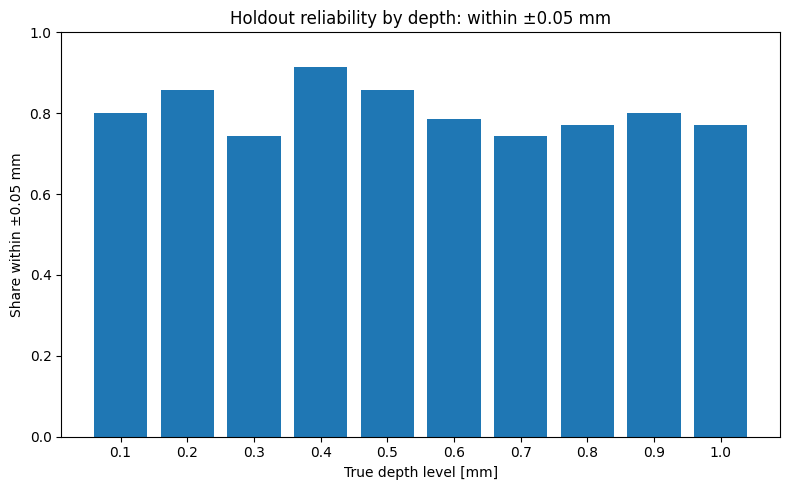

In [8]:
# ------------------------------------------------------------------
# PLOTS
# ------------------------------------------------------------------
# 1) Histogram of absolute error
plt.figure(figsize=(7, 5))
plt.hist(df["abs_error"], bins=25)
for tol in [0.05, 0.10]:
    plt.axvline(tol, linestyle="--", label=f"{tol:.2f} mm")
plt.xlabel("Absolute error [mm]")
plt.ylabel("Count")
plt.title("Holdout absolute error distribution")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "holdout_abs_error_hist.png", dpi=180)
plt.show()

# 2) Empirical CDF of absolute error
x = np.sort(df["abs_error"].to_numpy())
y = np.arange(1, len(x) + 1) / len(x)

plt.figure(figsize=(7, 5))
plt.plot(x, y)
for tol in [0.05, 0.10]:
    plt.axvline(tol, linestyle="--", label=f"{tol:.2f} mm")
plt.xlabel("Absolute error [mm]")
plt.ylabel("Empirical probability")
plt.title("Holdout empirical CDF of absolute error")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "holdout_abs_error_ecdf.png", dpi=180)
plt.show()

# 3) MAE by depth
plt.figure(figsize=(8, 5))
plt.bar(by_depth["depth_level"].astype(str), by_depth["mae_mm"])
plt.xlabel("True depth level [mm]")
plt.ylabel("MAE [mm]")
plt.title("Holdout MAE by true depth level")
plt.tight_layout()
plt.savefig(OUT_DIR / "holdout_mae_by_depth_reliability.png", dpi=180)
plt.show()

# 4) Share within ±0.05 mm by depth
plt.figure(figsize=(8, 5))
plt.bar(by_depth["depth_level"].astype(str), by_depth["p_abs_error_le_0.05_mm"])
plt.ylim(0, 1)
plt.xlabel("True depth level [mm]")
plt.ylabel("Share within ±0.05 mm")
plt.title("Holdout reliability by depth: within ±0.05 mm")
plt.tight_layout()
plt.savefig(OUT_DIR / "holdout_share_within_005_by_depth.png", dpi=180)
plt.show()

In [9]:
# ------------------------------------------------------------------
# OPTIONAL: WORST CASES
# ------------------------------------------------------------------
worst_cases = df.sort_values("abs_error", ascending=False).copy()
cols = [c for c in [record_col, group_col, "y_true", "y_pred", "residual", "abs_error"] if c is not None and c in worst_cases.columns]
worst_cases = worst_cases[cols]

worst_cases.head(20).to_csv(OUT_DIR / "holdout_worst_20_cases.csv", index=False)
worst_cases.head(20)

,record_name,run_id,y_true,y_pred,residual,abs_error
116,0503_9_1_1285__seg047__step047__E2__depth0.400...,0503_9_1_1285,0.4,0.6,-0.2,0.2
44,0503_12_1_6520__seg036__step036__C1__depth0.20...,0503_12_1_6520,0.2,0.4,-0.2,0.2
49,0503_3_1_0862__seg036__step036__C1__depth0.200...,0503_3_1_0862,0.2,0.4,-0.2,0.2
52,0503_9_1_1285__seg036__step036__C1__depth0.200...,0503_9_1_1285,0.2,0.4,-0.2,0.2
5,0503_9_1_1285__seg018__step018__B1__depth0.100...,0503_9_1_1285,0.1,0.3,-0.2,0.2
11,0503_12_1_6520__seg029__step029__D2__depth0.10...,0503_12_1_6520,0.1,0.3,-0.2,0.2
240,0503_3_1_0862__seg007__step007__A7__depth0.800...,0503_3_1_0862,0.8,0.6,0.2,0.2
324,0503_2_1_5344__seg009__step009__D3__depth1.000...,0503_2_1_5344,1.0,0.8,0.2,0.2
254,0503_2_1_5344__seg007__step007__A7__depth0.800...,0503_2_1_5344,0.8,0.6,0.2,0.2
220,0503_2_1_5344__seg014__step014__A1__depth0.700...,0503_2_1_5344,0.7,0.5,0.2,0.2


In [10]:
# ------------------------------------------------------------------
# FINAL THESIS-READY MINI TABLE
# ------------------------------------------------------------------
final_table = pd.DataFrame(
    {
        "metric": [
            "MAE [mm]",
            "Median absolute error [mm]",
            "75th percentile absolute error [mm]",
            "90th percentile absolute error [mm]",
            "95th percentile absolute error [mm]",
            "Share within ±0.05 mm",
            "Share within ±0.10 mm",
            "Share above ±0.10 mm",
        ],
        "value": [
            overall.loc[0, "mae_mm"],
            overall.loc[0, "median_abs_error_mm"],
            overall.loc[0, "p75_abs_error_mm"],
            overall.loc[0, "p90_abs_error_mm"],
            overall.loc[0, "p95_abs_error_mm"],
            overall.loc[0, "p_abs_error_le_0.05_mm"],
            overall.loc[0, "p_abs_error_le_0.10_mm"],
            overall.loc[0, "p_abs_error_gt_0.10_mm"],
        ],
    }
)
final_table.to_csv(OUT_DIR / "holdout_reliability_final_table.csv", index=False)
final_table

,metric,value
0,MAE [mm],2.244898e-02
1,Median absolute error [mm],0.000000e+00
2,75th percentile absolute error [mm],1.110223e-16
3,90th percentile absolute error [mm],1.000000e-01
4,95th percentile absolute error [mm],1.000000e-01
5,Share within ±0.05 mm,8.046647e-01
6,Share within ±0.10 mm,9.708455e-01
7,Share above ±0.10 mm,2.915452e-02


## Rounded-step decision with uncertainty band

This section turns the continuous regression output into a practical step decision:

- assign the prediction to the **nearest valid depth level**
- but **abstain / flag as uncertain** if the prediction lies too close to a boundary between two neighboring levels

With `UNCERTAINTY_BAND_MM = 0.015`, a prediction is only turned into a hard step decision if its distance to the nearest step boundary is greater than 0.015 mm.

That gives you two useful views:

- **confident-only accuracy**: how often the rounded step is correct when the model is confident enough to decide
- **coverage / abstention rate**: how often the model refuses to force a borderline call

In [11]:
ROUND_STEP_MM = DOE_STEP_MM
UNCERTAINTY_BAND_MM = 0.015

In [12]:
# ------------------------------------------------------------------
# ROUNDED-STEP DECISION WITH UNCERTAINTY BAND
# ------------------------------------------------------------------
valid_levels = np.sort(df["depth_level"].dropna().unique())
if len(valid_levels) < 2:
    raise ValueError("Need at least two distinct depth levels for step-based rounding analysis.")

def nearest_valid_level(value: float, levels: np.ndarray) -> float:
    idx = int(np.argmin(np.abs(levels - value)))
    return float(levels[idx])

boundaries = (valid_levels[:-1] + valid_levels[1:]) / 2.0

def distance_to_nearest_boundary(value: float, boundaries_arr: np.ndarray) -> float:
    if len(boundaries_arr) == 0:
        return np.inf
    return float(np.min(np.abs(boundaries_arr - value)))

rounded_df = df.copy()
rounded_df["nearest_step_pred"] = rounded_df["y_pred"].apply(lambda v: nearest_valid_level(v, valid_levels))
rounded_df["step_error_mm"] = rounded_df["nearest_step_pred"] - rounded_df["y_true"]
rounded_df["step_error_steps"] = rounded_df["step_error_mm"] / ROUND_STEP_MM
rounded_df["distance_to_nearest_boundary_mm"] = rounded_df["y_pred"].apply(
    lambda v: distance_to_nearest_boundary(v, boundaries)
)
rounded_df["is_uncertain"] = rounded_df["distance_to_nearest_boundary_mm"] <= UNCERTAINTY_BAND_MM
rounded_df["is_confident"] = ~rounded_df["is_uncertain"]
rounded_df["rounded_step_correct"] = rounded_df["nearest_step_pred"] == rounded_df["depth_level"]
rounded_df["rounded_step_correct_if_forced"] = rounded_df["rounded_step_correct"]
rounded_df["rounded_step_correct_with_abstention"] = rounded_df["rounded_step_correct"] & rounded_df["is_confident"]
rounded_df["abs_step_error_steps"] = np.abs(np.round(rounded_df["step_error_steps"]).astype(int))

rounded_df.to_csv(OUT_DIR / "holdout_rounded_step_with_uncertainty.csv", index=False)

rounded_overall = pd.DataFrame([
    {
        "n_rows": len(rounded_df),
        "n_confident": int(rounded_df["is_confident"].sum()),
        "n_uncertain": int(rounded_df["is_uncertain"].sum()),
        "coverage_confident": float(rounded_df["is_confident"].mean()),
        "abstention_rate": float(rounded_df["is_uncertain"].mean()),
        "forced_rounding_accuracy": float(rounded_df["rounded_step_correct_if_forced"].mean()),
        "confident_only_accuracy": float(
            rounded_df.loc[rounded_df["is_confident"], "rounded_step_correct"].mean()
        ) if rounded_df["is_confident"].any() else np.nan,
        "accuracy_with_abstention_as_not_decided": float(
            rounded_df["rounded_step_correct_with_abstention"].mean()
        ),
        "confident_off_by_1_or_more_rate": float(
            (rounded_df.loc[rounded_df["is_confident"], "abs_step_error_steps"] >= 1).mean()
        ) if rounded_df["is_confident"].any() else np.nan,
        "confident_off_by_2_or_more_rate": float(
            (rounded_df.loc[rounded_df["is_confident"], "abs_step_error_steps"] >= 2).mean()
        ) if rounded_df["is_confident"].any() else np.nan,
    }
])
rounded_overall.to_csv(OUT_DIR / "holdout_rounded_step_summary.csv", index=False)
rounded_overall

,n_rows,n_confident,n_uncertain,coverage_confident,abstention_rate,forced_rounding_accuracy,confident_only_accuracy,accuracy_with_abstention_as_not_decided,confident_off_by_1_or_more_rate,confident_off_by_2_or_more_rate
0,343,343,0,1.0,0.0,0.804665,0.804665,0.804665,0.195335,0.029155


In [13]:
# Thesis-ready statements for rounded-step mode
cov = rounded_overall.loc[0, "coverage_confident"]
abst = rounded_overall.loc[0, "abstention_rate"]
acc_forced = rounded_overall.loc[0, "forced_rounding_accuracy"]
acc_conf = rounded_overall.loc[0, "confident_only_accuracy"]
acc_abst = rounded_overall.loc[0, "accuracy_with_abstention_as_not_decided"]

print(f"Using an uncertainty band of ±{UNCERTAINTY_BAND_MM:.3f} mm around step boundaries:")
print(f"- {pct(cov)} of predictions receive a confident rounded-step decision.")
print(f"- {pct(abst)} are flagged as uncertain and withheld from hard step assignment.")
print(f"- If every prediction is forcibly rounded, step accuracy is {pct(acc_forced)}.")
print(f"- Among confident-only decisions, rounded-step accuracy is {pct(acc_conf)}.")
print(f"- If uncertain cases count as not decided, the overall correct-and-decided rate is {pct(acc_abst)}.")

Using an uncertainty band of ±0.015 mm around step boundaries:
- 100.0% of predictions receive a confident rounded-step decision.
- 0.0% are flagged as uncertain and withheld from hard step assignment.
- If every prediction is forcibly rounded, step accuracy is 80.5%.
- Among confident-only decisions, rounded-step accuracy is 80.5%.
- If uncertain cases count as not decided, the overall correct-and-decided rate is 80.5%.


In [14]:
# By depth level for rounded-step mode
by_depth_rounded = (
    rounded_df.groupby("depth_level", as_index=False)
    .agg(
        n_rows=("y_true", "size"),
        coverage_confident=("is_confident", "mean"),
        abstention_rate=("is_uncertain", "mean"),
        forced_rounding_accuracy=("rounded_step_correct_if_forced", "mean"),
        accuracy_with_abstention_as_not_decided=("rounded_step_correct_with_abstention", "mean"),
    )
    .sort_values("depth_level")
)

by_depth_rounded["confident_only_accuracy"] = (
    rounded_df.loc[rounded_df["is_confident"]]
    .groupby("depth_level")["rounded_step_correct"]
    .mean()
    .reindex(by_depth_rounded["depth_level"])
    .to_numpy()
)

by_depth_rounded.to_csv(OUT_DIR / "holdout_rounded_step_by_depth.csv", index=False)
by_depth_rounded

,depth_level,n_rows,coverage_confident,abstention_rate,forced_rounding_accuracy,accuracy_with_abstention_as_not_decided,confident_only_accuracy
0,0.1,35,1.0,0.0,0.800000,0.800000,0.800000
1,0.2,35,1.0,0.0,0.857143,0.857143,0.857143
2,0.3,35,1.0,0.0,0.742857,0.742857,0.742857
3,0.4,35,1.0,0.0,0.914286,0.914286,0.914286
4,0.5,35,1.0,0.0,0.857143,0.857143,0.857143
5,0.6,28,1.0,0.0,0.785714,0.785714,0.785714
6,0.7,35,1.0,0.0,0.742857,0.742857,0.742857
7,0.8,35,1.0,0.0,0.771429,0.771429,0.771429
8,0.9,35,1.0,0.0,0.800000,0.800000,0.800000
9,1.0,35,1.0,0.0,0.771429,0.771429,0.771429


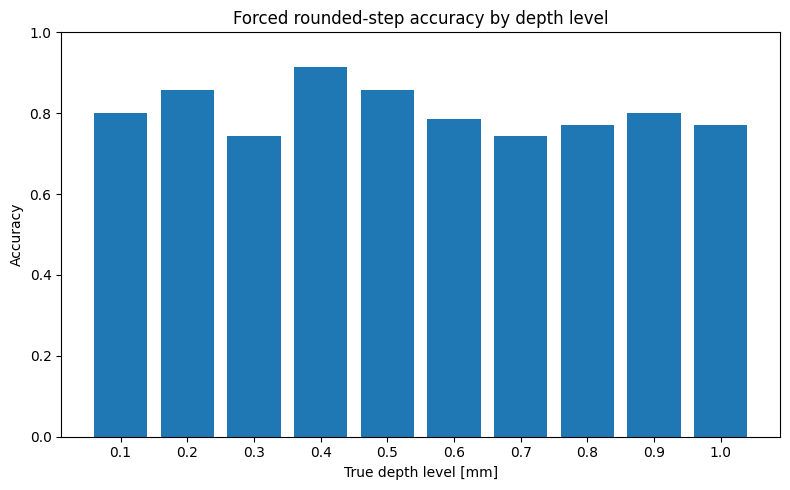

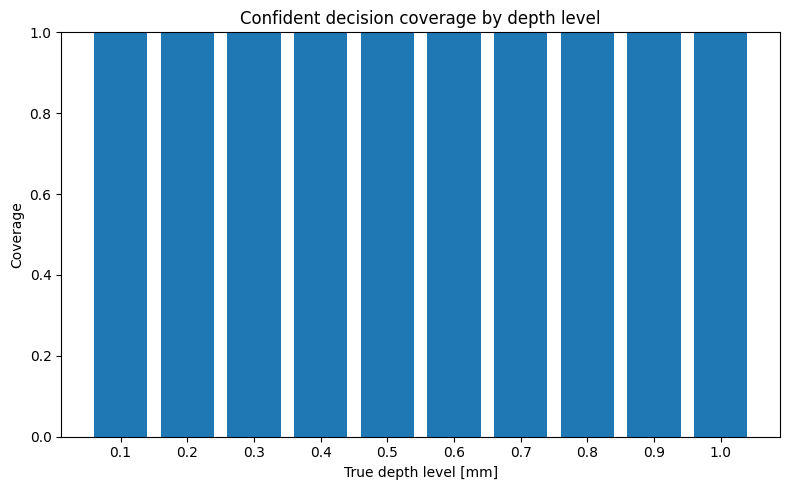

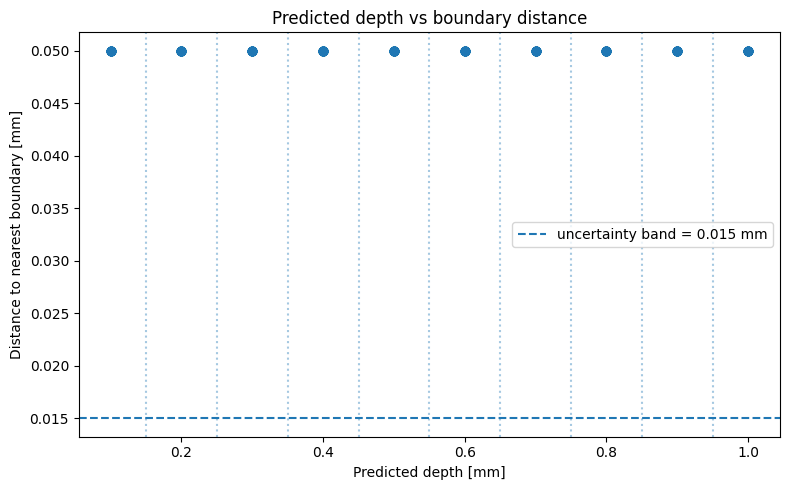

In [15]:
# Plots for rounded-step mode
plt.figure(figsize=(8, 5))
plt.bar(by_depth_rounded["depth_level"].astype(str), by_depth_rounded["forced_rounding_accuracy"])
plt.xlabel("True depth level [mm]")
plt.ylabel("Accuracy")
plt.title("Forced rounded-step accuracy by depth level")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / "rounded_step_forced_accuracy_by_depth.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(by_depth_rounded["depth_level"].astype(str), by_depth_rounded["coverage_confident"])
plt.xlabel("True depth level [mm]")
plt.ylabel("Coverage")
plt.title("Confident decision coverage by depth level")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(OUT_DIR / "rounded_step_coverage_by_depth.png", dpi=180)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    rounded_df["y_pred"],
    rounded_df["distance_to_nearest_boundary_mm"],
    alpha=0.7
)
plt.axhline(UNCERTAINTY_BAND_MM, linestyle="--", label=f"uncertainty band = {UNCERTAINTY_BAND_MM:.3f} mm")
for b in boundaries:
    plt.axvline(b, linestyle=":", alpha=0.4)
plt.xlabel("Predicted depth [mm]")
plt.ylabel("Distance to nearest boundary [mm]")
plt.title("Predicted depth vs boundary distance")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "rounded_step_boundary_distance_scatter.png", dpi=180)
plt.show()

In [16]:
# ------------------------------------------------------------------
# FINAL THESIS-READY MINI TABLE
# ------------------------------------------------------------------
final_table = pd.DataFrame(
    {
        "metric": [
            "MAE [mm]",
            "Median absolute error [mm]",
            "75th percentile absolute error [mm]",
            "90th percentile absolute error [mm]",
            "95th percentile absolute error [mm]",
            "Share within ±0.05 mm",
            "Share within ±0.10 mm",
            "Share above ±0.10 mm",
            f"Forced rounded-step accuracy (step = {ROUND_STEP_MM:.2f} mm)",
            f"Confident-only rounded-step accuracy (band = ±{UNCERTAINTY_BAND_MM:.3f} mm)",
            "Confident decision coverage",
            "Uncertain / abstained share",
        ],
        "value": [
            overall.loc[0, "mae_mm"],
            overall.loc[0, "median_abs_error_mm"],
            overall.loc[0, "p75_abs_error_mm"],
            overall.loc[0, "p90_abs_error_mm"],
            overall.loc[0, "p95_abs_error_mm"],
            overall.loc[0, "p_abs_error_le_0.05_mm"],
            overall.loc[0, "p_abs_error_le_0.10_mm"],
            overall.loc[0, "p_abs_error_gt_0.10_mm"],
            rounded_overall.loc[0, "forced_rounding_accuracy"],
            rounded_overall.loc[0, "confident_only_accuracy"],
            rounded_overall.loc[0, "coverage_confident"],
            rounded_overall.loc[0, "abstention_rate"],
        ],
    }
)
final_table.to_csv(OUT_DIR / "holdout_reliability_final_table.csv", index=False)
final_table

,metric,value
0,MAE [mm],2.244898e-02
1,Median absolute error [mm],0.000000e+00
2,75th percentile absolute error [mm],1.110223e-16
3,90th percentile absolute error [mm],1.000000e-01
4,95th percentile absolute error [mm],1.000000e-01
5,Share within ±0.05 mm,8.046647e-01
6,Share within ±0.10 mm,9.708455e-01
7,Share above ±0.10 mm,2.915452e-02
8,Forced rounded-step accuracy (step = 0.10 mm),8.046647e-01
9,Confident-only rounded-step accuracy (band = ±...,8.046647e-01


## What to report in plain language

Use the values from `final_table` or the printed statements above.

Example structure:

- *The holdout MAE was 0.0XYZ mm.*
- *The median absolute error was 0.0XYZ mm, while the 90th and 95th percentile absolute errors were 0.0XYZ mm and 0.0XYZ mm, respectively.*
- *XX.X% of holdout predictions were within ±0.05 mm and YY.Y% were within ±0.10 mm.*
- *ZZ.Z% exceeded ±0.10 mm, which quantifies the risk of a deviation larger than one full DOE step.*

That is much more defensible than waving one MAE around and hoping nobody asks rude questions.
